In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os
import warnings
warnings.filterwarnings('ignore')

# Load all our feature files
BASE = os.path.join('..', 'data', 'processed')

deliveries   = pd.read_csv(os.path.join(BASE, 'master_deliveries.csv'), low_memory=False)
batter_stats = pd.read_csv(os.path.join(BASE, 'batter_features.csv'))
bowler_stats = pd.read_csv(os.path.join(BASE, 'bowler_features.csv'))
season_trends= pd.read_csv(os.path.join(BASE, 'season_trends.csv'))
toss_impact  = pd.read_csv(os.path.join(BASE, 'toss_impact.csv'))

print("✅ All datasets loaded!")
print(f"   Deliveries: {len(deliveries):,}")
print(f"   Batters: {len(batter_stats):,}")
print(f"   Bowlers: {len(bowler_stats):,}")
print(f"   Seasons: {len(season_trends)}")

✅ All datasets loaded!
   Deliveries: 279,586
   Batters: 1,565
   Bowlers: 1,451
   Seasons: 19


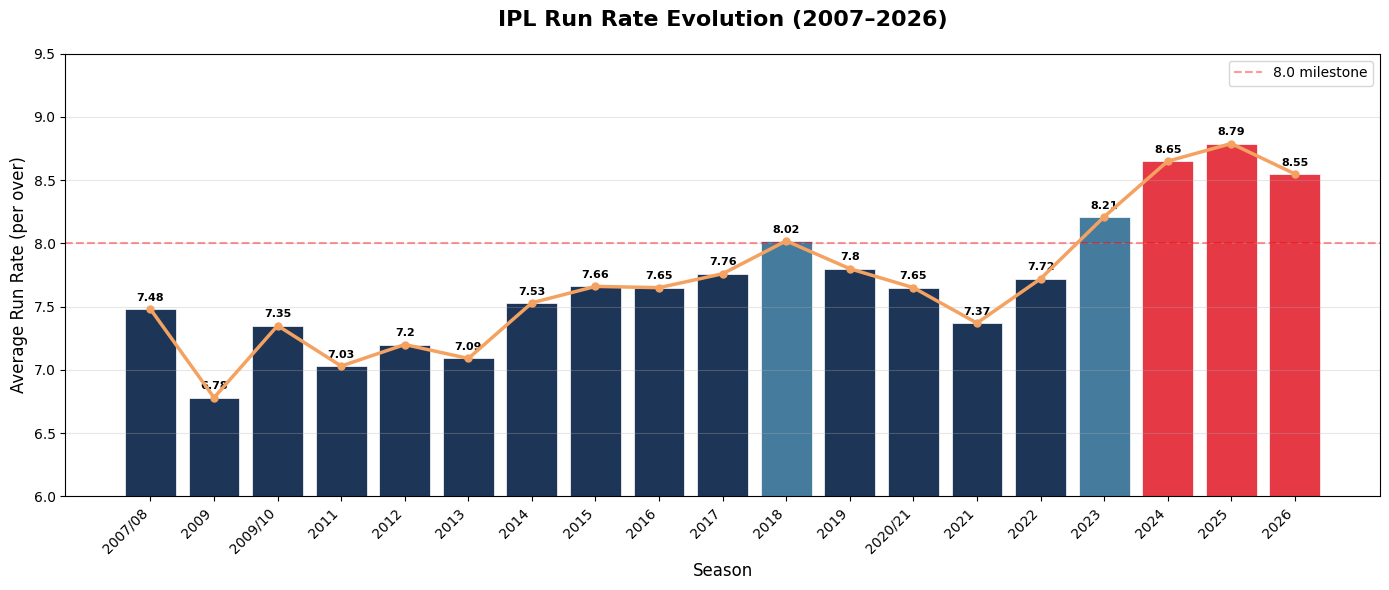

✅ Chart saved!


In [4]:
# Chart 1: IPL Run Rate Evolution across seasons
fig, ax = plt.subplots(figsize=(14, 6))

seasons = season_trends['season'].astype(str)
run_rates = season_trends['avg_run_rate']

bars = ax.bar(seasons, run_rates, color=[
    '#e63946' if r >= 8.5 else '#457b9d' if r >= 8.0 else '#1d3557' 
    for r in run_rates
], edgecolor='white', linewidth=0.5)

ax.plot(range(len(seasons)), run_rates, color='#f4a261', 
        linewidth=2.5, marker='o', markersize=5, zorder=5)

ax.set_title('IPL Run Rate Evolution (2007–2026)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Average Run Rate (per over)', fontsize=12)
ax.set_xticklabels(seasons, rotation=45, ha='right')
ax.set_ylim(6.0, 9.5)
ax.axhline(y=8.0, color='red', linestyle='--', alpha=0.4, label='8.0 milestone')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, rate in zip(bars, run_rates):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
            f'{rate}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/chart_run_rate_evolution.png', dpi=150)
plt.show()
print("✅ Chart saved!")

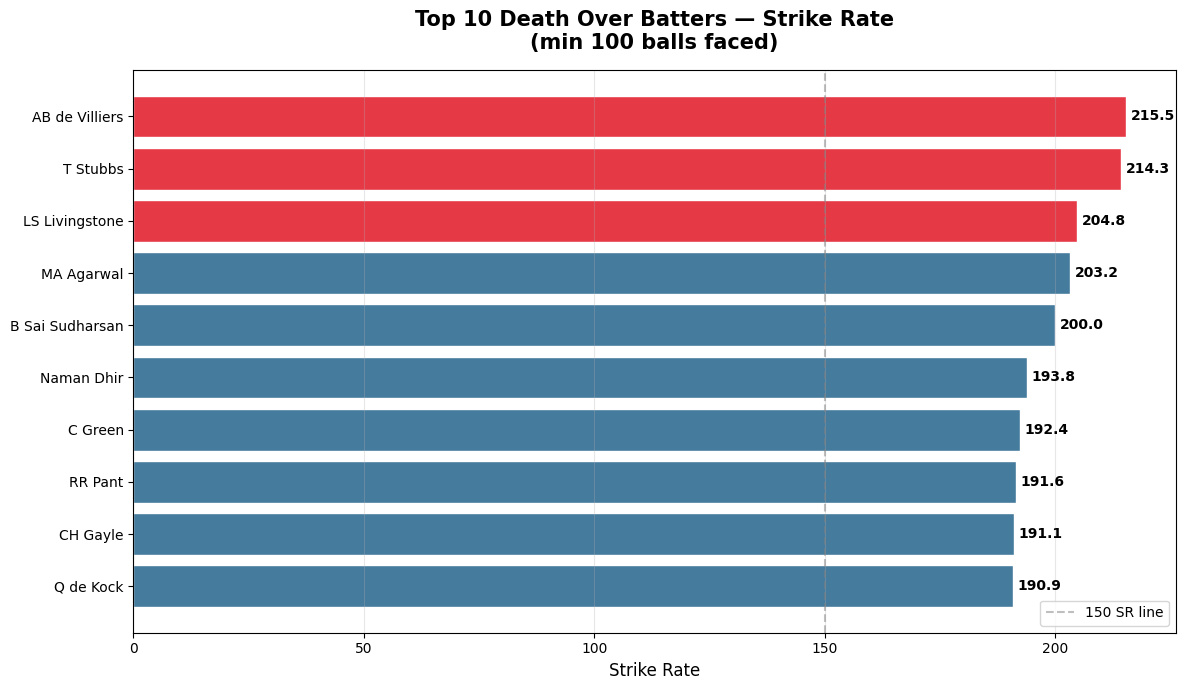

✅ Chart saved!


In [5]:
# Chart 2: Top 10 Death Over Batters by Strike Rate (min 100 balls)
death_batters = batter_stats[
    (batter_stats['phase'] == 'death') & 
    (batter_stats['balls_faced'] >= 100)
].sort_values('strike_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#e63946' if i < 3 else '#457b9d' for i in range(len(death_batters))]
bars = ax.barh(death_batters['striker'], death_batters['strike_rate'], 
               color=colors, edgecolor='white')

ax.set_title('Top 10 Death Over Batters — Strike Rate\n(min 100 balls faced)', 
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Strike Rate', fontsize=12)
ax.axvline(x=150, color='gray', linestyle='--', alpha=0.5, label='150 SR line')
ax.legend()

for bar, val in zip(bars, death_batters['strike_rate']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontweight='bold')

ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/chart_death_batters.png', dpi=150)
plt.show()
print("✅ Chart saved!")

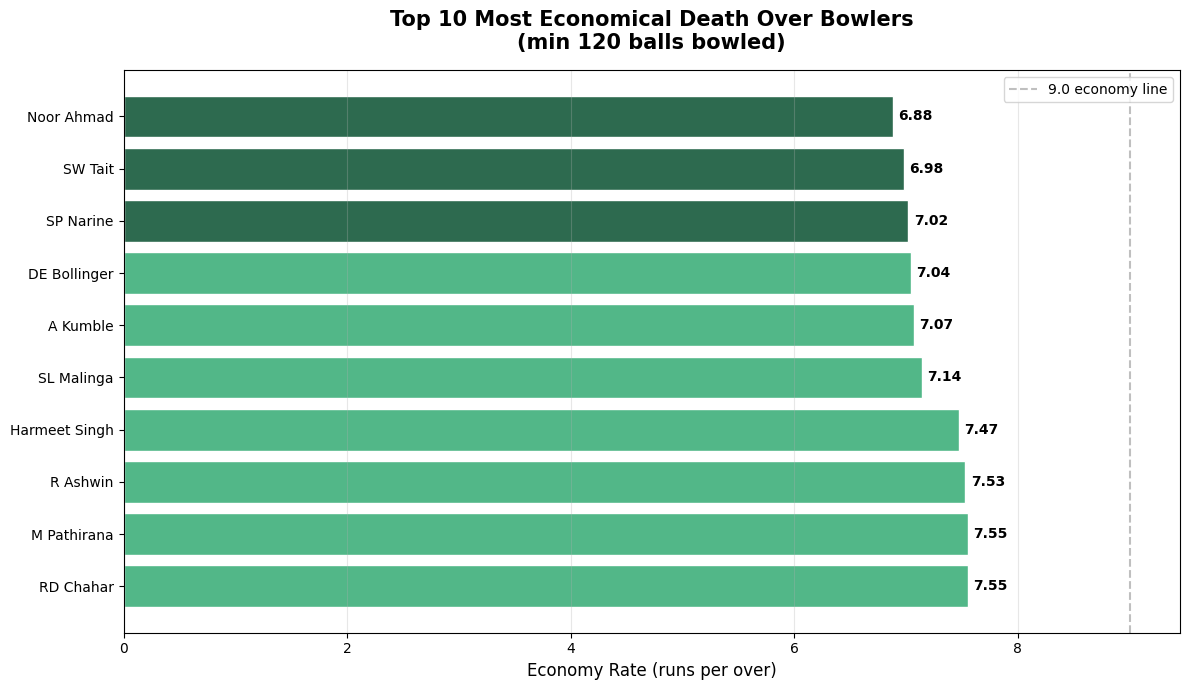

✅ Chart saved!


In [6]:
# Chart 3: Top 10 Most Economical Death Over Bowlers (min 120 balls)
death_bowlers = bowler_stats[
    (bowler_stats['phase'] == 'death') & 
    (bowler_stats['balls_bowled'] >= 120)
].sort_values('economy').head(10)

fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#2d6a4f' if i < 3 else '#52b788' for i in range(len(death_bowlers))]
bars = ax.barh(death_bowlers['bowler'], death_bowlers['economy'],
               color=colors, edgecolor='white')

ax.set_title('Top 10 Most Economical Death Over Bowlers\n(min 120 balls bowled)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Economy Rate (runs per over)', fontsize=12)
ax.axvline(x=9, color='gray', linestyle='--', alpha=0.5, label='9.0 economy line')
ax.legend()

for bar, val in zip(bars, death_bowlers['economy']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontweight='bold')

ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/chart_death_bowlers.png', dpi=150)
plt.show()
print("✅ Chart saved!")